In [11]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [12]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [13]:
save_path = os.path.expanduser('~/paper_cifar_models/cnn/pca-init-cifar/')
print('save_path:', save_path)
if not os.path.exists(save_path):
    os.makedirs(save_path)

save_path: /home/david/paper_cifar_models/cnn/pca-init-cifar/


In [14]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [15]:
def initialize_with_reduced_pca(model):
    # First reduce 3072 -> 1024 with PCA
    pca_reduce = PCA(n_components=1024)
    cifar_train = datasets.CIFAR10(root='./data', train=True, download=False, transform=transforms.ToTensor())
    flat_data = cifar_train.data.reshape(-1, 32 * 32 * 3).astype(np.float32)
    pca_reduce.fit(flat_data)

    # Transform data to 1024 dims
    reduced_features = pca_reduce.transform(flat_data)

    # Then PCA to 128 dims
    pca_final = PCA(n_components=128)
    pca_final.fit(reduced_features)

    with torch.no_grad():
        device = next(model.parameters()).device
        dtype = next(model.parameters()).dtype
        # pca_final.components_: shape (128, 1024) -> matches (out_features, in_features)
        pca_weight_tensor = torch.from_numpy(pca_final.components_.astype(np.float32)).to(device=device, dtype=dtype)
        model.encoder[-1].weight.copy_(pca_weight_tensor)
        model.encoder[-1].bias.zero_()

    return model

def initialize_sae_with_pca():
    """Initialize the ConvAutoencoder with PCA weights"""
    sae_model = ConvAutoencoder(latent_dim=128).to(device)
    sae_model = initialize_with_reduced_pca(sae_model)
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)
    return sae_model, sae_optimizer

In [16]:
for i in range(0, 1):
    save_path = os.path.join(os.path.expanduser('~'), 'cifar_models/sae-latent-pca-init', str(i))
    os.makedirs(save_path, exist_ok=True)

    sae_model_pca_init, sae_optimizer = initialize_sae_with_pca()

    train_loss, vali_loss = train_vali_all_epochs_conv(
                                                sae_model_pca_init,
                                                train_loader,
                                                validation_loader,
                                                sae_optimizer,
                                                60,
                                                device,
                                                save_path + '/',
                                                )

    np.save(os.path.join(save_path, 'train_loss.npy'), train_loss)
    np.save(os.path.join(save_path, 'vali_loss.npy'), vali_loss)

Train Epoch: 0 [19968/40000 (100%)]	Loss: 0.014868: 100%|██████████| 313/313 [00:04<00:00, 68.86it/s]


====> Epoch: 0 Average loss: 1.0012
====> Test set loss: 3065.8529
Weights saved.


Train Epoch: 1 [19968/40000 (100%)]	Loss: 0.014084: 100%|██████████| 313/313 [00:03<00:00, 88.91it/s]

====> Epoch: 1 Average loss: 0.9983


====> Test set loss: 3055.5035
Weights saved.


...

====> Epoch: 58 Average loss: 0.1743


====> Test set loss: 537.4603
Weights saved.


Train Epoch: 59 [19968/40000 (100%)]	Loss: 0.002956: 100%|██████████| 313/313 [00:06<00:00, 46.20it/s]

====> Epoch: 59 Average loss: 0.1740


====> Test set loss: 534.4524
Weights saved.


In [17]:
train_losses = []
vali_losses = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'vali_loss.npy'))
    train_losses.append(train_loss_i)
    vali_losses.append(vali_loss_i)

train_losses = np.stack(train_losses)
vali_losses = np.stack(vali_losses)

train_loss_mean = train_losses.mean(axis=0)
train_loss_std = train_losses.std(axis=0)
vali_loss_mean = vali_losses.mean(axis=0)
vali_loss_std = vali_losses.std(axis=0)

In [18]:
train_losses_pca = []
vali_losses_pca = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'vali_loss.npy'))
    train_losses_pca.append(train_loss_i)
    vali_losses_pca.append(vali_loss_i)

train_losses_pca = np.stack(train_losses_pca)
vali_losses_pca = np.stack(vali_losses_pca)

train_loss_mean_pca = train_losses_pca.mean(axis=0)
train_loss_std_pca = train_losses_pca.std(axis=0)
vali_loss_mean_pca = vali_losses_pca.mean(axis=0)
vali_loss_std_pca = vali_losses_pca.std(axis=0)

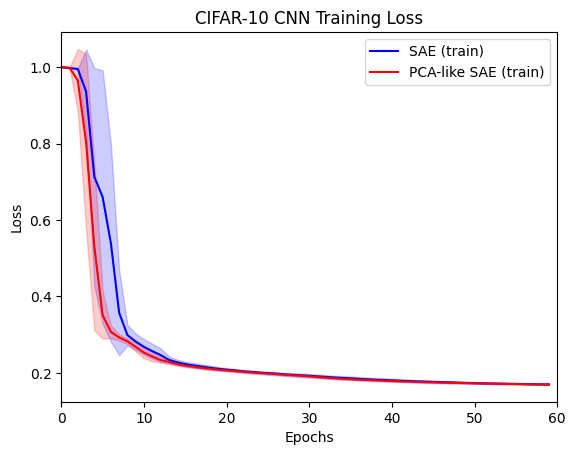

In [19]:
plt.plot(train_loss_mean, label='SAE (train)', color='blue')
plt.fill_between(np.arange(len(train_loss_mean)), train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
plt.plot(train_loss_mean_pca, label='PCA-like SAE (train)', color='red')
plt.fill_between(np.arange(len(train_loss_mean_pca)), train_loss_mean_pca - train_loss_std_pca, train_loss_mean_pca + train_loss_std_pca, alpha=0.2, color='red')
plt.legend()
plt.title('CIFAR-10 CNN Training Loss')
plt.xlabel('Epochs')
plt.xlim(0, 60)
plt.ylabel('Loss')
plt.show()

In [32]:
from rf_computation import compute_final_rfs

dae_rfs = compute_final_rfs(model_type='sae-latent-pca-init', dataset='cifar', size_ls=None, num_models=1, num_epochs=60, base_path=os.path.expanduser('~/'))

SAE-LATENT-PCA-INIT:   0%|          | 0/1 [00:00<?, ?it/s]

128
/home/david/cifar_models/sae-latent-pca-init/0/model_weights_epoch59.pth


SAE-LATENT-PCA-INIT: 100%|██████████| 1/1 [00:26<00:00, 26.32s/it]


In [33]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [34]:
dae_rfs.shape

AttributeError: 'list' object has no attribute 'shape'

In [35]:
# dae_rfs = np.load('Results/cifar_sae-latent-pca-init_final_rfs.npy')
dae_rfs = np.repeat(dae_rfs, 10, axis=0)
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
print(dae_rfs.shape)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

(10, 60, 128, 3, 32, 32)


In [24]:
sae_rfs = np.repeat(sae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
sae_rfs.shape

MemoryError: Unable to allocate 52.7 GiB for an array with shape (10, 60, 60, 128, 3, 32, 32) and data type float32

In [36]:
dae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [37]:
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [38]:
np.save('Results/cifar_sae_rfs.npy', sae_rfs)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

In [39]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=dae_rfs, num_models=10, epoch=0)

100%|██████████| 10/10 [00:00<00:00, 25.47it/s]


In [29]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cnn', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


NameError: name 'fig' is not defined

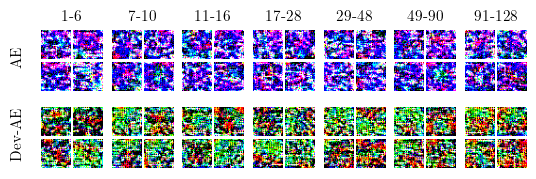

In [40]:
from plot_example_rfs import plot_example_rfs

fig = plt.figure(figsize=(6.26, 1.9))
ax = fig.add_subplot(111)
plot_example_rfs(ax, dataset='cifar', epoch_idx=59)
plt.close(fig)